In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch

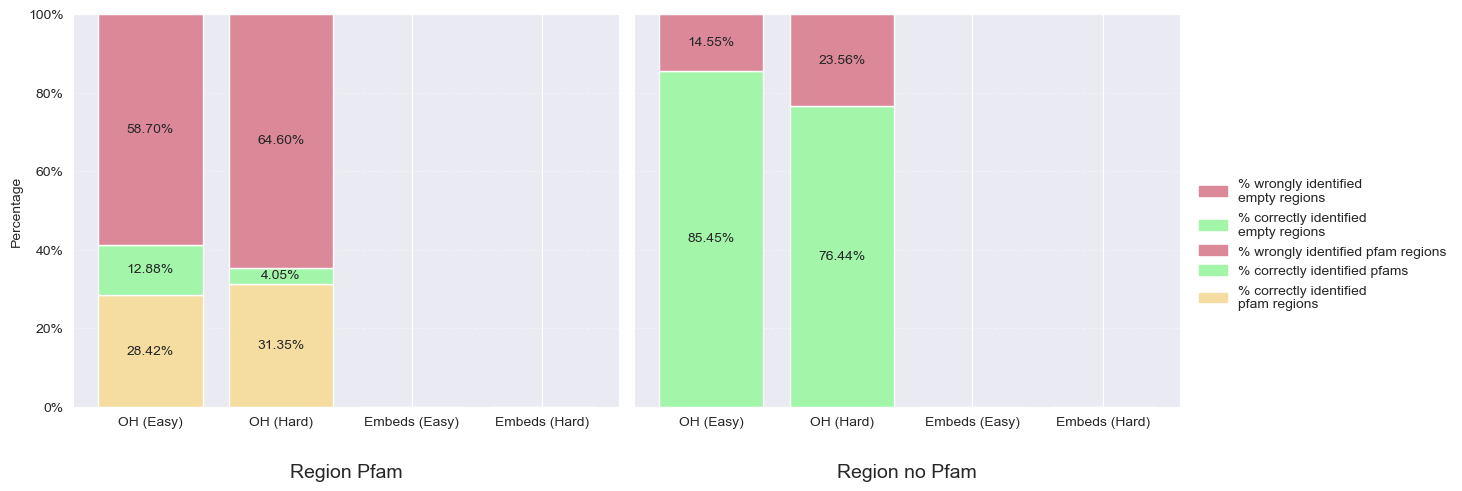

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch

# 1) define the data (four categories → four values per series)
categories = ['OH (Easy)', 'OH (Hard)',
              'Embeds (Easy)', 'Embeds (Hard)']
data = {
    'Region Pfam': {
        '% correctly identified\npfam regions':    [41.30 - 12.88, 35.40 - 4.05,  0,   0],

        '% correctly identified pfams':            [12.88,  4.05,  0,   0],

        '% wrongly identified pfam regions':       [100 - 41.30,
                                                   100 - 35.40,
                                                   0,
                                                   0],
    },
    'Region no Pfam': {
        '% correctly identified\nempty regions':   [85.45, 76.44,  0,   0],
        '% wrongly identified\nempty regions':     [100 - 85.45,
                                                   100 - 76.44,
                                                   0,
                                                   0],
    }
}

# 2) colors
colors = {
    '% correctly identified\npfam regions': '#f5dda2',
    '% correctly identified pfams':         '#a2f5a9',
    '% wrongly identified pfam regions':    '#db8899',

    '% correctly identified\nempty regions': '#a2f5a9',
    '% wrongly identified\nempty regions':    '#db8899',
}

# 3) two subplots (one per “Region”), share the y‐axis, with centered labels
fig, axes = plt.subplots(1, len(data), figsize=(12, 5), sharey=True)
x = np.arange(len(categories))

for ax, (region, series_dict) in zip(axes, data.items()):
    bottom = np.zeros(len(categories))

    for name, vals in series_dict.items():
        bars = ax.bar(x, vals,
                      bottom=bottom,
                      color=colors[name],
                      label=name)
        # annotate each segment
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,  # x center
                    bot + val/2,                       # y center of segment
                    f"{val:.2f}%",                     # label text
                    ha='center', va='center',
                    fontsize=10
                )
        bottom += np.array(vals)

    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, ha='center')
    ax.set_title(region, y=-0.2, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# 4) format the leftmost y‐axis as percentages
axes[0].set_ylabel('Percentage')
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=100))

# 5) single legend on the right
legend_handles = [Patch(color=colors[n], label=n)
                  for n in reversed(colors.keys())]
fig.legend(handles=legend_handles,
           loc='center right',
           bbox_to_anchor=(1.22, 0.5),
           frameon=False)

# 6) make room for the legend and save
fig.subplots_adjust(right=0.78)  # pull the plot region in to fit legend
plt.tight_layout()
plt.savefig('dataset/plots/pfam_stacked_bar_charts.png',
            dpi=300,
            bbox_inches='tight')
plt.show()


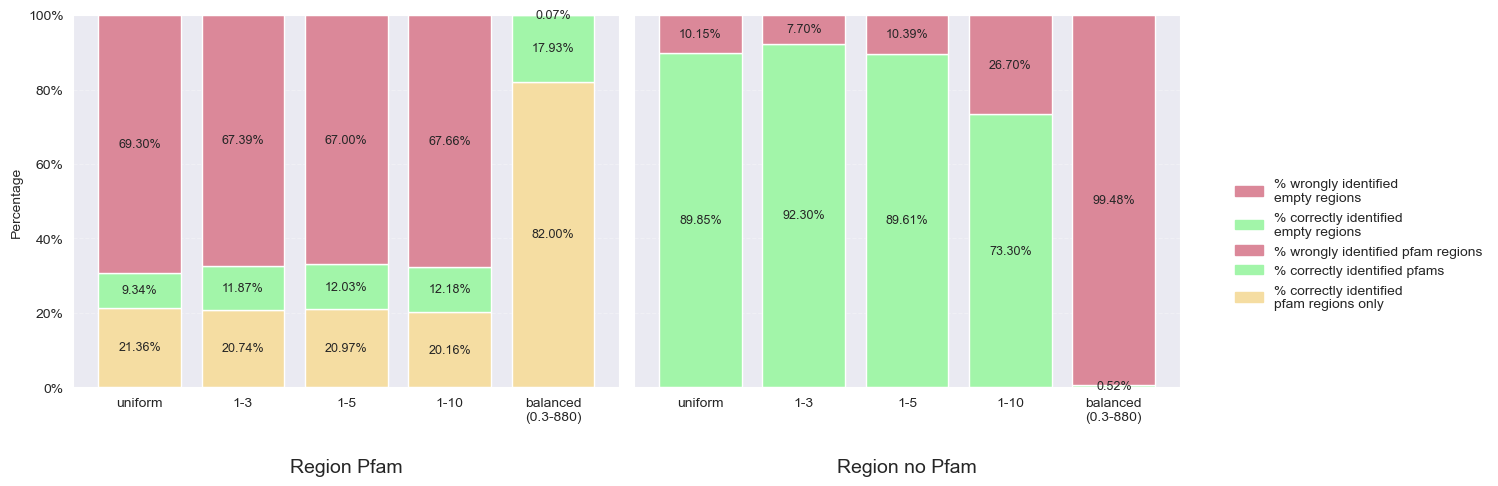

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch

# 1) Define the data (five weight settings → values per series)
categories = ['uniform', '1-3', '1-5', '1-10', 'balanced\n(0.3-880)']
data = {
    'Region Pfam': {
        # 'regions only' = total region % minus the pfam sub‐portion
        '% correctly identified\npfam regions only': [
            30.70 - 9.34,
            32.61 - 11.87,
            33.00 - 12.03,
            32.34 - 12.18,
            99.93 - 17.93
        ],
        '% correctly identified pfams': [
            9.34,
            11.87,
            12.03,
            12.18,
            17.93
        ],
        '% wrongly identified pfam regions': [
            100 - 30.70,
            100 - 32.61,
            100 - 33.00,
            100 - 32.34,
            100 - 99.93
        ]
    },
    'Region no Pfam': {
        '% correctly identified\nempty regions': [
            89.85,
            92.30,
            89.61,
            73.30,
            0.52
        ],
        '% wrongly identified\nempty regions': [
            100 - 89.85,
            100 - 92.30,
            100 - 89.61,
            100 - 73.30,
            100 - 0.52
        ]
    }
}

# 2) Define colors
colors = {
    '% correctly identified\npfam regions only': '#f5dda2',
    '% correctly identified pfams':          '#a2f5a9',
    '% wrongly identified pfam regions':     '#db8899',
    '% correctly identified\nempty regions': '#a2f5a9',
    '% wrongly identified\nempty regions':    '#db8899',
}

# 3) Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
x = np.arange(len(categories))

for ax, (region, series_dict) in zip(axes, data.items()):
    bottom = np.zeros(len(categories))
    for label, vals in series_dict.items():
        bars = ax.bar(x, vals, bottom=bottom, color=colors[label], label=label)
        # Annotate each segment
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bot + val/2,
                    f"{val:.2f}%",
                    ha='center', va='center', fontsize=9
                )
        bottom += np.array(vals)
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, ha='center')
    ax.set_title(region, y=-0.25, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# 4) Format y‐axis as percentages
axes[0].set_ylabel('Percentage')
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=100))

# 5) Single legend on the right
legend_handles = [Patch(color=colors[k], label=k) for k in reversed(colors.keys())]
fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(1.25, 0.5), frameon=False)

# 6) Adjust layout & show
fig.subplots_adjust(right=0.8)
plt.tight_layout()
plt.show()
